In [ ]:
import sys

from pathlib import Path

print(sys.executable)

print(Path.cwd())


### STEP 1. 예측 문제와 예측 시점을 먼저 정의합니다

무엇을 예측하는가?

예측 단위는 무엇인가?

언제 예측하는가?

그 시점에 실제로 알 수 있는 정보는 무엇인가?

### STEP 2. Feature Leakage Audit을 수행합니다

In [2]:
import pandas as pd
from pathlib import Path

# ===== 0. 경로: notebooks/ 에서 실행해도, 프로젝트 루트에서 실행해도 동작 =====
ROOT = Path.cwd() if (Path.cwd() / "data" / "raw").exists() else Path.cwd().parent
RAW = ROOT / "data" / "raw"

customers   = pd.read_csv(RAW / "customers.csv",   encoding="utf-8-sig")
orders      = pd.read_csv(RAW / "orders.csv",      encoding="utf-8-sig")
order_items = pd.read_csv(RAW / "order_items.csv", encoding="utf-8-sig")
products    = pd.read_csv(RAW / "products.csv",    encoding="utf-8-sig")

raw_cols = {}
for name, t in {"customers": customers, "orders": orders,
                "order_items": order_items, "products": products}.items():
    for c in t.columns:
        raw_cols.setdefault(c, []).append(name)

# ===== 1. Audit 규칙 =====
# (예측 시점 사용 가능, Target 계산 재료, 사후 정보/ID, 최종 사용, 구분, 판단 이유)
rules = {
    # --- 허용 (주문 메타데이터 + 고객 비식별 특성) ---
    "order_month":     ("O","X","X","사용","허용",        "order_date에서 파생. 주문 시점에 이미 알 수 있음"),
    "order_dayofweek": ("O","X","X","사용","허용",        "order_date에서 파생. 주문 시점에 이미 알 수 있음"),
    "payment_method":  ("O","X","X","사용","허용",        "orders의 주문 메타데이터. 주문 시점에 결정됨"),
    "age":             ("O","X","X","사용","허용",        "customers의 고객 비식별 특성. 주문 전부터 알 수 있음"),
    "gender":          ("O","X","X","사용","허용",        "customers의 고객 비식별 특성. 주문 전부터 알 수 있음"),
    "city":            ("O","X","X","사용","허용",        "customers의 고객 비식별 특성. 주문 전부터 알 수 있음"),
    # --- Target 자체 ---
    "order_total":     ("X","O","X","제외","Target 자체",   "order_id별 line_total 합계 = 예측 대상 그 자체"),
    # --- Target 계산 재료 / 대리 변수 ---
    "line_total":      ("X","O","X","제외","Target 계산 재료","quantity × unit_price. 합치면 order_total이 됨"),
    "quantity":        ("X","O","X","제외","Target 계산 재료","order_items 상세 수량. 예측 시점에 입력으로 제공되지 않음"),
    "unit_price":      ("X","O","X","제외","Target 계산 재료","order_items 상세 단가. 예측 시점에 입력으로 제공되지 않음"),
    "item_count":      ("X","O","X","제외","Target 대리 변수","주문 상세 건수 집계. 주문 상세를 알아야 계산 가능"),
    "total_quantity":  ("X","O","X","제외","Target 대리 변수","quantity 합계. Target 계산 재료의 집계"),
    "avg_unit_price":  ("X","O","X","제외","Target 대리 변수","unit_price 평균. Target 계산 재료의 집계"),
    "price":           ("X","O","X","제외","Target 대리 변수","products 정가. 어떤 상품을 샀는지(주문 상세)를 알아야 연결됨"),
    "category":        ("X","O","X","제외","Target 대리 변수","products 카테고리. 주문 상세(product_id)를 통해서만 연결됨"),
    "product_name":    ("X","X","O","제외","식별자",        "상품별 고유 이름. 주문 상세 정보이며 사실상 ID"),
    # --- 사후 정보 ---
    "order_status":    ("X","X","O","제외","사후 정보",     "completed/cancelled 등은 주문 이후에 확정되는 결과"),
    # --- 식별자 ---
    "order_id":        ("X","X","O","제외","식별자",        "의미 없는 번호. 암기(과적합) 위험"),
    "customer_id":     ("X","X","O","제외","식별자",        "고객 번호. 새 고객에 일반화 불가, 암기 위험"),
    "product_id":      ("X","X","O","제외","식별자",        "상품 번호이자 주문 상세 정보"),
    "order_item_id":   ("X","X","O","제외","식별자",        "주문 상세 행 번호"),
    "name":            ("X","X","O","제외","식별자",        "고객 실명 = 개인정보. 모델 입력·공개 모두 금지"),
    # --- 기타 제외 ---
    "order_date":      ("O","X","X","제외","기타 제외",     "원본 날짜는 시간 분할 기준으로만 사용하고, month/dayofweek로 파생해서 입력"),
    "signup_date":     ("O","X","X","제외","기타 제외",     "예측 시점에 알 수 있지만 이번 실습 허용 feature 기준에 없음 (추후 가입기간 feature 후보)"),
}

# ===== 2. Audit 표 생성 (원본 컬럼 + 파생 feature 전부 포함) =====
all_features = list(dict.fromkeys(list(raw_cols) + list(rules)))
rows = []
for f in all_features:
    avail, tgt, post, use, kind, reason = rules.get(
        f, ("?","?","?","확인 필요","미분류","규칙에 없는 컬럼. 직접 판단 필요"))
    rows.append({
        "feature": f,
        "출처": ", ".join(raw_cols.get(f, ["(파생)"])),
        "예측 시점 사용 가능": avail,
        "Target 계산 재료": tgt,
        "사후 정보/ID": post,
        "최종 사용": use,
        "구분": kind,
        "판단 이유": reason,
    })

order = {"사용": 0, "확인 필요": 1, "제외": 2}
audit_df = (pd.DataFrame(rows)
              .sort_values("최종 사용", key=lambda s: s.map(order), kind="stable")
              .reset_index(drop=True))

pd.set_option("display.max_colwidth", None)
display(audit_df.style.set_properties(**{"text-align": "left"})
        .set_table_styles([{"selector": "th", "props": [("text-align", "left")]}]))

# ===== 3. 결과 요약 + 금지 feature 겹침 검사 =====
FEATURES  = audit_df.loc[audit_df["최종 사용"] == "사용", "feature"].tolist()
FORBIDDEN = audit_df.loc[audit_df["최종 사용"] == "제외", "feature"].tolist()
unknown   = audit_df.loc[audit_df["최종 사용"] == "확인 필요", "feature"].tolist()
overlap   = set(FEATURES) & set(FORBIDDEN)

print(f"✅ 사용 feature ({len(FEATURES)}개): {FEATURES}")
print(f"❌ 제외 feature ({len(FORBIDDEN)}개): {FORBIDDEN}")
print(f"⚠️ 확인 필요: {unknown if unknown else '없음'}")
print(f"🔒 forbidden_feature_overlap = {len(overlap)} → {'PASS' if not overlap and not unknown else 'FAIL'}")

# ===== 4. Evidence 저장 =====
(ROOT / "reports").mkdir(exist_ok=True)
audit_df.to_csv(ROOT / "reports" / "ch09_regression_feature_audit.csv", index=False, encoding="utf-8-sig")
print("💾 저장: reports/ch09_regression_feature_audit.csv")

,feature,출처,예측 시점 사용 가능,Target 계산 재료,사후 정보/ID,최종 사용,구분,판단 이유
0,gender,customers,O,X,X,사용,허용,customers의 고객 비식별 특성. 주문 전부터 알 수 있음
1,age,customers,O,X,X,사용,허용,customers의 고객 비식별 특성. 주문 전부터 알 수 있음
2,city,customers,O,X,X,사용,허용,customers의 고객 비식별 특성. 주문 전부터 알 수 있음
3,payment_method,orders,O,X,X,사용,허용,orders의 주문 메타데이터. 주문 시점에 결정됨
4,order_month,(파생),O,X,X,사용,허용,order_date에서 파생. 주문 시점에 이미 알 수 있음
5,order_dayofweek,(파생),O,X,X,사용,허용,order_date에서 파생. 주문 시점에 이미 알 수 있음
6,customer_id,"customers, orders",X,X,O,제외,식별자,"고객 번호. 새 고객에 일반화 불가, 암기 위험"
7,name,customers,X,X,O,제외,식별자,고객 실명 = 개인정보. 모델 입력·공개 모두 금지
8,signup_date,customers,O,X,X,제외,기타 제외,예측 시점에 알 수 있지만 이번 실습 허용 feature 기준에 없음 (추후 가입기간 feature 후보)
9,order_id,"orders, order_items",X,X,O,제외,식별자,의미 없는 번호. 암기(과적합) 위험


✅ 사용 feature (6개): ['gender', 'age', 'city', 'payment_method', 'order_month', 'order_dayofweek']
❌ 제외 feature (18개): ['customer_id', 'name', 'signup_date', 'order_id', 'order_date', 'order_status', 'order_item_id', 'product_id', 'quantity', 'unit_price', 'product_name', 'category', 'price', 'order_total', 'line_total', 'item_count', 'total_quantity', 'avg_unit_price']
⚠️ 확인 필요: 없음
🔒 forbidden_feature_overlap = 0 → PASS
💾 저장: reports/ch09_regression_feature_audit.csv


## Feature Leakage Audit 결과

![STEP 2 Feature Leakage Audit](images/step02_leakage.png)

### 결과 관찰
- 원본 4개 파일과 파생 컬럼, 총 24개 feature를 점검했다.
- 최종 사용 feature는 6개다: gender, age, city, payment_method, order_month, order_dayofweek
- forbidden_feature_overlap = 0 (PASS)

### 제외 feature 분류
- **Target 자체**: order_total
- **Target 계산 재료·대리 변수**: line_total, quantity, unit_price, item_count, total_quantity, avg_unit_price, price, category
- **예측 시점 이후 정보**: order_status
- **식별자**: order_id, customer_id, product_id, order_item_id, product_name, name(개인정보)
- **기타**: order_date(시간 분할 기준으로만 사용), signup_date(허용 기준에 없음)

### 나의 해석과 판단
- 예측 시점에는 주문 상세(어떤 상품을 몇 개, 얼마에)를 모른다고 가정했다. 그래서 order_items와 products에서 오는 정보는 모두 제외했다.
- price와 category는 가이드의 금지 목록에는 없다. 하지만 product_id를 통해서만 주문과 연결되므로 주문 상세 정보로 판단해 제외했다.

### 한계와 추가 확인 사항
- 남은 feature 6개는 모두 고객 특성이나 날짜 정보라서, 주문 금액을 설명할 신호가 부족할 수 있다. (가설)
- signup_date로 만든 가입 기간은 누수 없이 쓸 수 있는 feature 후보다.

### STEP 3. Target 생성과 관계 검증을 확인합니다

In [4]:
import pandas as pd
from pathlib import Path

# ===== 0. 경로 & 원본 로드 =====
ROOT = Path.cwd() if (Path.cwd() / "data" / "raw").exists() else Path.cwd().parent
RAW = ROOT / "data" / "raw"
read = lambda f: pd.read_csv(RAW / f, encoding="utf-8-sig")
customers, orders, order_items, products = (read(f) for f in
    ["customers.csv", "orders.csv", "order_items.csv", "products.csv"])
orders["order_date"] = pd.to_datetime(orders["order_date"])

# ===== 1. 원본 FK 관계 점검 (조용히 넘어가지 않고 먼저 드러낸다) =====
orphan_items   = order_items[~order_items["order_id"].isin(orders["order_id"])]        # Target은 있는데 부모 주문 없음
orphan_orders  = orders[~orders["customer_id"].isin(customers["customer_id"])]          # 주문의 고객이 customers에 없음
no_target      = orders[~orders["order_id"].isin(order_items["order_id"])]              # 주문은 있는데 Target 없음
unknown_prod   = order_items[~order_items["product_id"].isin(products["product_id"])]   # 상품 마스터에 없는 상품

raw_fk = pd.DataFrame([
    ("order_items → orders (부모 주문 없음)",   len(orphan_items),  orphan_items["order_id"].tolist()),
    ("orders → customers (고객 없음)",         len(orphan_orders), orphan_orders["order_id"].tolist()),
    ("orders → order_items (Target 없음)",     len(no_target),     no_target["order_id"].tolist()),
    ("order_items → products (상품 없음)",     len(unknown_prod),  unknown_prod["order_id"].tolist()),
], columns=["원본 관계 점검", "문제 건수", "관련 order_id"])
print("■ 1. 원본 FK 관계 점검")
display(raw_fk)

# ===== 2. 관계 오류 처리: 문제 주문은 모델링에서 명시적으로 제외 =====
bad_order_ids = set(orphan_items["order_id"]) | set(orphan_orders["order_id"]) | set(unknown_prod["order_id"])
orders_c = orders[~orders["order_id"].isin(bad_order_ids)].copy()
items_c  = order_items[~order_items["order_id"].isin(bad_order_ids)].copy()
print(f"\n■ 2. 제외한 order_id: {sorted(bad_order_ids)}")
print(f"   orders {len(orders)} → {len(orders_c)}행 / order_items {len(order_items)} → {len(items_c)}행")

# ===== 3. Target 생성 =====
items_c["line_total"] = items_c["quantity"] * items_c["unit_price"]

# 저장된 line_total이 있으면 재계산 값과 비교 (현재 원본에는 line_total 컬럼이 없음)
if "line_total" in order_items.columns:
    stored = order_items.set_index("order_item_id")["line_total"]
    line_mismatch = int((stored.reindex(items_c["order_item_id"]).values != items_c["line_total"].values).sum())
    line_note = "저장값 vs 재계산 비교"
else:
    line_mismatch = 0
    line_note = "원본에 line_total 없음 → quantity × unit_price로 새로 계산"

# 참고: 주문 단가 vs 상품 정가 불일치
price_chk = items_c.merge(products[["product_id", "price"]], on="product_id", how="left")
price_mismatch = int((price_chk["unit_price"] != price_chk["price"]).sum())

target = (items_c.groupby("order_id", as_index=False)["line_total"].sum()
                 .rename(columns={"line_total": "order_total"}))

# ===== 4. 관계 검증 (validate로 강제, 위반 시 에러) =====
m1 = orders_c.merge(target, on="order_id", how="outer", validate="one_to_one", indicator=True)
m2 = m1.merge(customers, on="customer_id", how="left", validate="many_to_one", indicator="_cust")

checks = pd.DataFrame([
    ("line_total 계산식",               "quantity × unit_price",            "INFO"),
    ("line_total 불일치 건수",          f"{line_mismatch} ({line_note})",   "PASS" if line_mismatch == 0 else "FAIL"),
    ("unit_price ≠ products.price",     price_mismatch,                     "INFO"),
    ("order_total 계산식",              "order_id별 line_total 합계",       "INFO"),
    ("orders ↔ order_total one_to_one", "validate 통과",                    "PASS"),
    ("주문은 있는데 Target 없음",        int((m1["_merge"] == "left_only").sum()),  None),
    ("Target은 있는데 부모 주문 없음",   int((m1["_merge"] == "right_only").sum()), None),
    ("orders → customers many_to_one",  "validate 통과",                    "PASS"),
    ("주문의 customer_id가 customers에 없음", int((m2["_cust"] == "left_only").sum()), None),
], columns=["check", "value", "status"])
checks["status"] = checks["status"].fillna(checks["value"].map(lambda v: "PASS" if v == 0 else "FAIL"))
print("\n■ 3~4. Target 생성과 관계 검증")
display(checks)

all_pass = (checks["status"] != "FAIL").all()
assert all_pass, "❌ 관계 검증 FAIL → 모델링 진행 금지"
print("✅ 관계 검증 전체 PASS")

# ===== 5. 모델링 입력 생성 (STEP 2에서 확정한 feature만 사용) =====
model_df = m2[m2["_merge"] == "both"].copy()
model_df["order_month"]     = model_df["order_date"].dt.month
model_df["order_dayofweek"] = model_df["order_date"].dt.dayofweek   # 0=월 ~ 6=일

FEATURES = ["gender", "age", "city", "payment_method", "order_month", "order_dayofweek"]
TARGET = "order_total"
model_df = (model_df[["order_id", "order_date"] + FEATURES + [TARGET]]
              .sort_values("order_date").reset_index(drop=True))

print(f"\n■ 5. 모델링 입력: {model_df.shape[0]}행 × feature {len(FEATURES)}개 + Target")
print(f"   기간: {model_df['order_date'].min().date()} ~ {model_df['order_date'].max().date()}")
display(model_df.head())
display(model_df[TARGET].describe().to_frame().T)

# ===== 6. 저장 (PASS일 때만 도달) =====
(ROOT / "data" / "processed").mkdir(parents=True, exist_ok=True)
(ROOT / "reports").mkdir(exist_ok=True)
model_df.to_csv(ROOT / "data" / "processed" / "ch09_model_data.csv", index=False, encoding="utf-8-sig")
evidence = pd.concat([
    raw_fk.assign(section="원본 FK 점검").rename(columns={"원본 관계 점검": "check", "문제 건수": "value", "관련 order_id": "note"}),
    checks.assign(section="Target·관계 검증"),
], ignore_index=True)[["section", "check", "value", "status", "note"]]
evidence.to_csv(ROOT / "reports" / "ch09_regression_target_check.csv", index=False, encoding="utf-8-sig")
print("💾 저장: data/processed/ch09_model_data.csv (Internal: order_id 포함)")
print("💾 저장: reports/ch09_regression_target_check.csv")

■ 1. 원본 FK 관계 점검


,원본 관계 점검,문제 건수,관련 order_id
0,order_items → orders (부모 주문 없음),1,[400]
1,orders → customers (고객 없음),1,[301]
2,orders → order_items (Target 없음),0,[]
3,order_items → products (상품 없음),1,[301]



■ 2. 제외한 order_id: [301, 400]
   orders 301 → 300행 / order_items 766 → 764행

■ 3~4. Target 생성과 관계 검증


,check,value,status
0,line_total 계산식,quantity × unit_price,INFO
1,line_total 불일치 건수,0 (원본에 line_total 없음 → quantity × unit_price로 새로 계산),PASS
2,unit_price ≠ products.price,0,INFO
3,order_total 계산식,order_id별 line_total 합계,INFO
4,orders ↔ order_total one_to_one,validate 통과,PASS
5,주문은 있는데 Target 없음,0,PASS
6,Target은 있는데 부모 주문 없음,0,PASS
7,orders → customers many_to_one,validate 통과,PASS
8,주문의 customer_id가 customers에 없음,0,PASS


✅ 관계 검증 전체 PASS

■ 5. 모델링 입력: 300행 × feature 6개 + Target
   기간: 2025-08-08 ~ 2026-08-08


,order_id,order_date,gender,age,city,payment_method,order_month,order_dayofweek,order_total
0,85,2025-08-08,F,22,서울,bank_transfer,8,4,755000
1,283,2025-08-11,F,22,대구,naver_pay,8,0,284000
2,38,2025-08-13,F,34,부산,bank_transfer,8,2,303000
3,252,2025-08-21,F,23,울산,card,8,3,1549000
4,227,2025-08-21,F,47,고양,card,8,3,361000


,count,mean,std,min,25%,50%,75%,max
order_total,300.0,852033.333333,515967.441049,10000.0,413750.0,807000.0,1173000.0,2821000.0


💾 저장: data/processed/ch09_model_data.csv (Internal: order_id 포함)
💾 저장: reports/ch09_regression_target_check.csv


## Target 생성과 관계 검증
- line_total 계산식: quantity × unit_price
- order_total 계산식: order_id별 line_total 합계
- line_total 불일치 건수: 0 (원본에 line_total이 없어 직접 계산함)
- 원본 관계 오류: order_id 400(부모 주문 없음), order_id 301(고객·상품 마스터에 없음) → 2건 제외
- orders ↔ target 관계 결과: one_to_one PASS (주문 300건 = Target 300건)
- orders → customers 관계 결과: many_to_one PASS
- 관계 검증 없이 병합할 경우의 위험: 부모 없는 주문 상세가 Target에 섞이거나, inner join으로 조용히 행이 사라지거나, 고객 정보가 결측(NaN)인 주문이 학습에 들어갈 수 있다.

### STEP 4. Train / Final Test 시간 분할

In [ ]:
import pandas as pd
from pathlib import Path

# ===== 0. STEP 3 결과 불러오기 (메모리에 없어도 파일로 재현 가능) =====
ROOT = Path.cwd() if (Path.cwd() / "data" / "raw").exists() else Path.cwd().parent
model_df = pd.read_csv(ROOT / "data" / "processed" / "ch09_model_data.csv",
                       encoding="utf-8-sig", parse_dates=["order_date"])
FEATURES = ["gender", "age", "city", "payment_method", "order_month", "order_dayofweek"]
TARGET = "order_total"

# ===== 1. 시간 순서 분할: 마지막 약 20%를 Final Test로 =====
TEST_RATIO = 0.2
model_df = model_df.sort_values("order_date").reset_index(drop=True)

# 날짜 단위로 자르기 → 같은 날짜가 Train/Test 양쪽에 들어가지 않음
cutoff_date = model_df["order_date"].iloc[int(len(model_df) * (1 - TEST_RATIO))]
train_df = model_df[model_df["order_date"] <  cutoff_date].copy()
test_df  = model_df[model_df["order_date"] >= cutoff_date].copy()

X_train, y_train = train_df[FEATURES], train_df[TARGET]
X_test,  y_test  = test_df[FEATURES],  test_df[TARGET]

# ===== 2. 분할 요약 =====
overlap_dates = set(train_df["order_date"].dt.date) & set(test_df["order_date"].dt.date)
split_summary = pd.DataFrame([
    {"split": "Train",      "시작일": train_df["order_date"].min().date(), "종료일": train_df["order_date"].max().date(),
     "행 수": len(train_df), "비율": f"{len(train_df)/len(model_df):.1%}", "Target 평균": round(y_train.mean())},
    {"split": "Final Test", "시작일": test_df["order_date"].min().date(),  "종료일": test_df["order_date"].max().date(),
     "행 수": len(test_df),  "비율": f"{len(test_df)/len(model_df):.1%}",  "Target 평균": round(y_test.mean())},
])
print("■ Train / Final Test 시간 분할")
display(split_summary)

# ===== 3. 분할 검증 =====
split_checks = pd.DataFrame([
    ("strict_train_before_test", f"{train_df['order_date'].max().date()} < {test_df['order_date'].min().date()}",
     "PASS" if train_df["order_date"].max() < test_df["order_date"].min() else "FAIL"),
    ("same_date_overlap",        len(overlap_dates),                     "PASS" if not overlap_dates else "FAIL"),
    ("rows_preserved",           f"{len(train_df)} + {len(test_df)} = {len(model_df)}",
     "PASS" if len(train_df) + len(test_df) == len(model_df) else "FAIL"),
], columns=["check", "value", "status"])
display(split_checks)
assert (split_checks["status"] == "PASS").all(), "❌ 시간 분할 검증 FAIL"
print("✅ 시간 분할 검증 전체 PASS")
print("🔒 Final Test(test_df)는 STEP 9 전까지 사용하지 않습니다.")

# ===== 4. Evidence 저장 =====
(ROOT / "reports").mkdir(exist_ok=True)
split_summary.to_csv(ROOT / "reports" / "ch09_regression_split_summary.csv", index=False, encoding="utf-8-sig")
print("💾 저장: reports/ch09_regression_split_summary.csv")

■ Train / Final Test 시간 분할


,split,시작일,종료일,행 수,비율,Target 평균
0,Train,2025-08-08,2026-05-24,240,80.0%,857838
1,Final Test,2026-05-25,2026-08-08,60,20.0%,828817


,check,value,status
0,strict_train_before_test,2026-05-24 < 2026-05-25,PASS
1,same_date_overlap,0,PASS
2,rows_preserved,240 + 60 = 300,PASS


✅ 시간 분할 검증 전체 PASS
🔒 Final Test(test_df)는 STEP 9 전까지 사용하지 않습니다.
💾 저장: reports/ch09_regression_split_summary.csv


## Train / Final Test 시간 분할
- Train: 2025-08-08 ~ 2026-05-24 (240행)
- Final Test: 2026-05-25 ~ 2026-08-08 (60행)
- 같은 날짜 overlap: 0건 (strict_train_before_test PASS)

### 왜 랜덤 분할이 아니라 시간 순서 분할인가?
실제로 모델을 쓸 때는 과거 주문으로 학습하고 앞으로 들어올 주문을 예측한다.
랜덤으로 나누면 미래 주문이 학습에 섞여서, 실제 사용 환경보다 점수가 좋게 나올 수 있다.
시간 순서로 나눠야 "처음 보는 미래 기간"에서 얼마나 맞히는지를 정직하게 평가할 수 있다.

### STEP 5~6. Pipeline 전처리 + Baseline·후보 모델 준비

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# ===== STEP 5. 전처리는 Pipeline 내부에서 =====
NUM_FEATURES = ["age", "order_month", "order_dayofweek"]
CAT_FEATURES = ["gender", "city", "payment_method"]
assert set(NUM_FEATURES + CAT_FEATURES) == set(FEATURES), "FEATURES와 전처리 컬럼 불일치"

def make_preprocessor():
    num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
    ])
    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot",  OneHotEncoder(handle_unknown="ignore")),
    ])
    return ColumnTransformer([
        ("num", num_pipe, NUM_FEATURES),
        ("cat", cat_pipe, CAT_FEATURES),
    ])

# ===== STEP 6. Baseline + 후보 모델 =====
RANDOM_STATE = 42
candidates = {
    "Baseline Mean":     DummyRegressor(strategy="mean"),
    "Linear Regression": LinearRegression(),
    "Random Forest":     RandomForestRegressor(n_estimators=200, min_samples_leaf=5,
                                               random_state=RANDOM_STATE, n_jobs=-1),
}
# 모델마다 전처리를 새로 만들어 붙임 → fit은 항상 각 Train(또는 Train Fold)에서만 일어남
pipelines = {name: Pipeline([("prep", make_preprocessor()), ("model", model)])
             for name, model in candidates.items()}

display(pd.DataFrame([
    {"구분": "숫자형",  "컬럼": ", ".join(NUM_FEATURES), "처리": "median imputation → StandardScaler"},
    {"구분": "범주형",  "컬럼": ", ".join(CAT_FEATURES), "처리": "most_frequent imputation → OneHotEncoder(handle_unknown='ignore')"},
    {"구분": "fit 범위", "컬럼": "-", "처리": "Pipeline.fit(X_train) 또는 CV의 각 Train Fold에서만 fit, Validation/Final Test는 transform만"},
]))
display(pd.DataFrame([{"모델": n, "역할": "baseline" if n == "Baseline Mean" else "candidate",
                       "설정": " ".join(str(m).split())} for n, m in candidates.items()]))
print("✅ Pipeline 3개 준비 완료 (아직 아무 데이터에도 fit하지 않음)")
print("   Train 결측치:", int(X_train.isna().sum().sum()), "건")

,구분,컬럼,처리
0,숫자형,"age, order_month, order_dayofweek",median imputation → StandardScaler
1,범주형,"gender, city, payment_method",most_frequent imputation → OneHotEncoder(handle_unknown='ignore')
2,fit 범위,-,"Pipeline.fit(X_train) 또는 CV의 각 Train Fold에서만 fit, Validation/Final Test는 transform만"


,모델,역할,설정
0,Baseline Mean,baseline,DummyRegressor()
1,Linear Regression,candidate,LinearRegression()
2,Random Forest,candidate,"RandomForestRegressor(min_samples_leaf=5, n_estimators=200, n_jobs=-1, random_state=42)"


✅ Pipeline 3개 준비 완료 (아직 아무 데이터에도 fit하지 않음)
   Train 결측치: 0 건


## 전처리 누수 방지
- 숫자형 처리: age, order_month, order_dayofweek → median imputation → StandardScaler
- 범주형 처리: gender, city, payment_method → most_frequent imputation → OneHotEncoder(handle_unknown="ignore")
- 전처리 fit 범위: Pipeline 안에서 Train(또는 CV의 Train Fold)에만 fit하고, Validation/Final Test에는 transform만 적용
- 전체 데이터에 먼저 fit하면 안 되는 이유: 평균, 표준편차, 최빈값 같은 통계에 미래(Test) 데이터 정보가 섞여 들어간다. 그러면 평가 점수가 실제보다 좋게 나올 수 있다.

## Baseline과 후보 모델
- Baseline Mean: DummyRegressor(strategy="mean")
- 후보: Linear Regression, Random Forest
- Random Forest가 더 복잡하다는 사실만으로 평균 예측보다 낫다고 말할 수 없다. Train CV로 실제로 비교해 봐야 한다.

### STEP 7~8. Train TimeSeriesSplit 비교 + Selected Model 고정

In [8]:
import numpy as np
from sklearn.model_selection import TimeSeriesSplit, cross_validate

# ===== STEP 7. Train 기간 안에서만 TimeSeriesSplit으로 후보 비교 =====
# (X_train, y_train은 STEP 4에서 order_date 순으로 정렬된 상태 → 시간 순서 유지)
N_SPLITS = 5
tscv = TimeSeriesSplit(n_splits=N_SPLITS)

# fold별 기간 확인: 항상 과거로 학습 → 바로 다음 기간으로 검증
fold_info = []
for k, (tr_idx, va_idx) in enumerate(tscv.split(X_train), 1):
    d_tr, d_va = train_df["order_date"].iloc[tr_idx], train_df["order_date"].iloc[va_idx]
    fold_info.append({"fold": k, "train 기간": f"{d_tr.min().date()} ~ {d_tr.max().date()}", "train 행": len(tr_idx),
                      "valid 기간": f"{d_va.min().date()} ~ {d_va.max().date()}", "valid 행": len(va_idx)})
print("■ TimeSeriesSplit fold 구성 (Final Test는 포함되지 않음)")
display(pd.DataFrame(fold_info))

cv_rows, fold_rows = [], []
for name, pipe in pipelines.items():
    res = cross_validate(pipe, X_train, y_train, cv=tscv,
                         scoring={"MAE": "neg_mean_absolute_error", "R2": "r2"})
    mae, r2 = -res["test_MAE"], res["test_R2"]
    cv_rows.append({"model": name, "role": "baseline" if name == "Baseline Mean" else "candidate",
                    "cv_MAE_mean": round(mae.mean()), "cv_MAE_std": round(mae.std()),
                    "cv_R2_mean": round(r2.mean(), 4)})
    fold_rows += [{"model": name, "fold": k + 1, "MAE": round(m), "R2": round(r, 4)}
                  for k, (m, r) in enumerate(zip(mae, r2))]

cv_summary = pd.DataFrame(cv_rows)
print("\n■ Train CV 결과 요약")
display(cv_summary)
print("■ fold별 MAE (흔들림 확인)")
display(pd.DataFrame(fold_rows).pivot(index="model", columns="fold", values="MAE"))

# ===== STEP 8. Final Test 보기 전에 Selected Model 고정 =====
# 규칙: 비베이스라인 후보 중 cv_MAE_mean이 가장 낮은 모델
non_base = cv_summary[cv_summary["role"] == "candidate"]
SELECTED_MODEL = non_base.loc[non_base["cv_MAE_mean"].idxmin(), "model"]
selected_row = cv_summary.set_index("model").loc[SELECTED_MODEL]
base_row     = cv_summary.set_index("model").loc["Baseline Mean"]

print("\n" + "=" * 60)
print(f"🧊 Selected Model (고정): {SELECTED_MODEL}")
print(f"   선택 기준: 비베이스라인 후보 중 Train CV MAE 평균 최소")
print(f"   근거 cv_MAE_mean: {selected_row['cv_MAE_mean']:,} (± {selected_row['cv_MAE_std']:,})")
print(f"   참고 Baseline cv_MAE_mean: {base_row['cv_MAE_mean']:,}")
print(f"   Final Test를 보기 전에 선택했는가: 예")
print("=" * 60)

# ===== Evidence 저장 =====
cv_summary.assign(selected=cv_summary["model"].eq(SELECTED_MODEL)).to_csv(
    ROOT / "reports" / "ch09_regression_cv_summary.csv", index=False, encoding="utf-8-sig")
print("💾 저장: reports/ch09_regression_cv_summary.csv")

■ TimeSeriesSplit fold 구성 (Final Test는 포함되지 않음)


,fold,train 기간,train 행,valid 기간,valid 행
0,1,2025-08-08 ~ 2025-10-07,40,2025-10-09 ~ 2025-11-23,40
1,2,2025-08-08 ~ 2025-11-23,80,2025-11-25 ~ 2026-01-19,40
2,3,2025-08-08 ~ 2026-01-19,120,2026-01-19 ~ 2026-02-25,40
3,4,2025-08-08 ~ 2026-02-25,160,2026-02-25 ~ 2026-04-06,40
4,5,2025-08-08 ~ 2026-04-06,200,2026-04-07 ~ 2026-05-24,40



■ Train CV 결과 요약


,model,role,cv_MAE_mean,cv_MAE_std,cv_R2_mean
0,Baseline Mean,baseline,414037,62120,-0.0153
1,Linear Regression,candidate,513895,181406,-0.6444
2,Random Forest,candidate,442765,66207,-0.1662


■ fold별 MAE (흔들림 확인)


fold,1,2,3,4,5
model,,,,,
Baseline Mean,522510,351621,431957,356900,407198
Linear Regression,873311,469491,419602,395201,411870
Random Forest,560431,387062,468085,383021,415224



🧊 Selected Model (고정): Random Forest
   선택 기준: 비베이스라인 후보 중 Train CV MAE 평균 최소
   근거 cv_MAE_mean: 442,765 (± 66,207)
   참고 Baseline cv_MAE_mean: 414,037
   Final Test를 보기 전에 선택했는가: 예
💾 저장: reports/ch09_regression_cv_summary.csv


## Train TimeSeriesSplit 후보 비교

| 모델 | CV MAE 평균 | CV MAE 표준편차 | CV R² 평균 | 비고 |
|---|---|---|---|---|
| Baseline Mean | 414,037 | 62,120 | -0.015 | 기준점 |
| Linear Regression | 513,895 | 181,406 | -0.644 | fold 간 흔들림 큼 (fold1 MAE 873,311) |
| Random Forest | 442,765 | 66,207 | -0.166 | 비베이스라인 중 MAE 최소 |

### 결과 관찰
- 두 후보 모두 Train CV MAE가 Baseline Mean보다 크다.
- Linear Regression은 fold 간 표준편차가 커서 결과가 불안정하다.

### 나의 해석과 판단 (가설)
- 현재 feature 6개(고객 특성과 날짜)만으로는 주문 금액을 설명할 신호가 부족할 수 있다.

## Train CV로 선택한 모델
- Selected Model: Random Forest
- 선택 기준: 비베이스라인 후보 중 cv_MAE_mean 최소
- 근거가 된 cv_MAE_mean: 442,765
- Final Test를 보기 전에 선택했는가: 예

### STEP 9~10. Final Test 개봉 (Baseline vs Frozen Model)

In [9]:
from sklearn.base import clone
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ===== STEP 9. Final Test 개봉: Baseline vs Frozen Selected Model만 평가 =====
# SELECTED_MODEL은 STEP 8에서 고정된 값 → 여기서 절대 바꾸지 않음
final_models = {
    "Baseline Mean": ("baseline", clone(pipelines["Baseline Mean"])),
    f"Frozen {SELECTED_MODEL}": ("selected_by_train_cv", clone(pipelines[SELECTED_MODEL])),
}

rows, test_preds = [], {}
for name, (role, pipe) in final_models.items():
    pipe.fit(X_train, y_train)                 # Train 전체로 다시 학습 (전처리 fit도 Train에서만)
    pred_tr, pred_te = pipe.predict(X_train), pipe.predict(X_test)   # Test는 transform + predict만
    test_preds[name] = pred_te
    rows.append({
        "model": name, "selection_role": role,
        "train_MAE": round(mean_absolute_error(y_train, pred_tr)),
        "test_MAE":  round(mean_absolute_error(y_test, pred_te)),
        "test_RMSE": round(np.sqrt(mean_squared_error(y_test, pred_te))),
        "test_R2":   round(r2_score(y_test, pred_te), 4),
    })

comparison = pd.DataFrame(rows)
base_mae = comparison.loc[comparison["selection_role"] == "baseline", "test_MAE"].iloc[0]
comparison["MAE_improvement_vs_baseline_pct"] = ((base_mae - comparison["test_MAE"]) / base_mae * 100).round(2)
comparison["RMSE/MAE"] = (comparison["test_RMSE"] / comparison["test_MAE"]).round(2)

print(f"■ Final Test 결과 (Test {len(y_test)}행, {test_df['order_date'].min().date()} ~ {test_df['order_date'].max().date()})")
display(comparison)

# ===== STEP 10. 지표 해석 보조 =====
sel = comparison.iloc[1]
print("\n■ 해석 보조")
print(f"  Test 실제 order_total 평균: {y_test.mean():,.0f}원 / 중앙값: {y_test.median():,.0f}원")
print(f"  MAE  : 평균적으로 실제 주문 금액과 약 {sel['test_MAE']:,}원 차이")
print(f"  RMSE : MAE의 {sel['RMSE/MAE']}배 → {'일부 큰 오차가 전체를 끌어올림' if sel['RMSE/MAE'] >= 1.3 else '큰 오차 쏠림은 크지 않음'}")
r2 = sel["test_R2"]
print(f"  R²   : {r2} → " + ("평균 예측보다 낮은 설명력" if r2 < 0 else "평균 예측과 비슷한 수준" if r2 < 0.1 else "평균 예측보다 변동을 더 설명"))
print(f"  Baseline 대비 MAE 개선율: {sel['MAE_improvement_vs_baseline_pct']}% "
      + ("(개선)" if sel["MAE_improvement_vs_baseline_pct"] > 0 else "(Baseline보다 나쁨)"))
print("\n⚠️ 결과가 기대보다 낮아도 다른 후보로 교체하지 않습니다.")

# 이후 STEP 11에서 사용할 Frozen 모델
frozen_pipe = final_models[f"Frozen {SELECTED_MODEL}"][1]

# ===== Evidence 저장 =====
comparison.to_csv(ROOT / "reports" / "ch09_regression_model_comparison.csv", index=False, encoding="utf-8-sig")
print("💾 저장: reports/ch09_regression_model_comparison.csv")

■ Final Test 결과 (Test 60행, 2026-05-25 ~ 2026-08-08)


,model,selection_role,train_MAE,test_MAE,test_RMSE,test_R2,MAE_improvement_vs_baseline_pct,RMSE/MAE
0,Baseline Mean,baseline,412933,455562,572033,-0.0026,0.00,1.26
1,Frozen Random Forest,selected_by_train_cv,325739,451811,578482,-0.0253,0.82,1.28



■ 해석 보조
  Test 실제 order_total 평균: 828,817원 / 중앙값: 739,500원
  MAE  : 평균적으로 실제 주문 금액과 약 451,811원 차이
  RMSE : MAE의 1.28배 → 큰 오차 쏠림은 크지 않음
  R²   : -0.0253 → 평균 예측보다 낮은 설명력
  Baseline 대비 MAE 개선율: 0.82% (개선)

⚠️ 결과가 기대보다 낮아도 다른 후보로 교체하지 않습니다.
💾 저장: reports/ch09_regression_model_comparison.csv


## Final Test 해석

### 결과 관찰
- MAE: 451,811원 (Baseline 455,562원)
- RMSE: 578,482원 (Baseline 572,033원), RMSE/MAE = 1.28
- R²: -0.025 (Baseline -0.003)
- Baseline 대비 MAE 개선율: +0.82%
- Train MAE 325,739원 → Test MAE 451,811원

### 나의 해석과 판단
- MAE는 아주 조금 줄었지만 RMSE와 R²는 Baseline보다 나쁘다. 평균값으로 예측하는 것보다 의미 있게 낫다고 보기 어렵다.
- R²가 음수인 것은 코드 오류가 아니라, 모델이 평균 예측보다 변동을 설명하지 못했다는 뜻이다.
- Train과 Test의 MAE 차이가 커서 과적합 가능성이 있다. (가설)

### 업무·분석적 의미
- 평균 주문 금액(약 83만 원) 대비 평균 오차가 약 45만 원이다. 개별 주문 금액 예측에 쓰기는 어렵다.

### 현재 한계
- feature가 고객 특성과 날짜 6개뿐이라 주문 금액을 설명할 신호가 부족할 수 있다. (가설)
- Final Test가 60건이라 지표가 쉽게 흔들릴 수 있다.

### STEP 11. 대표 오차 사례 진단

■ 예측값 vs 실제값 분포


,count,mean,std,min,25%,50%,75%,max
실제,60.0,828817.0,576118.0,50000.0,383000.0,739500.0,1124750.0,2821000.0
예측,60.0,885547.0,112934.0,711259.0,796133.0,885588.0,944537.0,1145021.0


■ residual 방향 요약


,건수,평균오차
방향,,
과대예측(실제보다 높게),35,435892.0
과소예측(실제보다 낮게),25,474097.0


■ 대표 큰 오차 사례 Top 3 (abs_error 기준)


,order_date,gender,age,city,payment_method,order_month,order_dayofweek,actual_order_total,predicted_order_total,residual,abs_error,방향
244,2026-05-31,F,35,수원,kakao_pay,5,6,2821000,891352.0,1929648.0,1929648.0,과소예측(실제보다 낮게)
249,2026-06-06,M,38,부산,naver_pay,6,5,2118000,908778.0,1209222.0,1209222.0,과소예측(실제보다 낮게)
253,2026-06-13,M,19,부산,bank_transfer,6,5,2053000,854965.0,1198035.0,1198035.0,과소예측(실제보다 낮게)


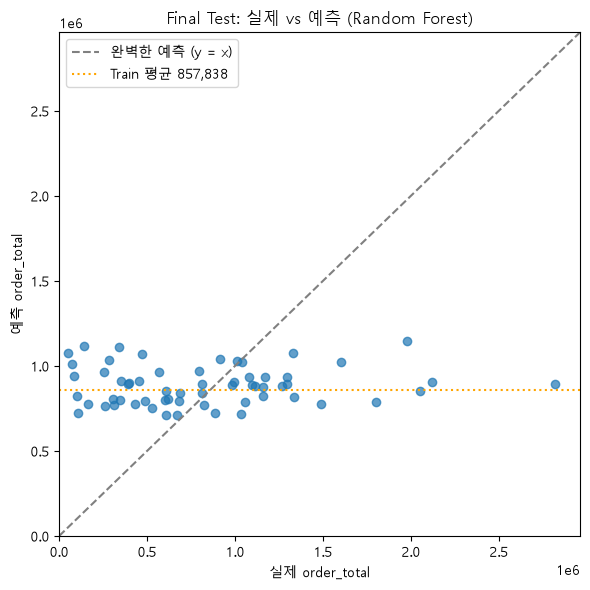

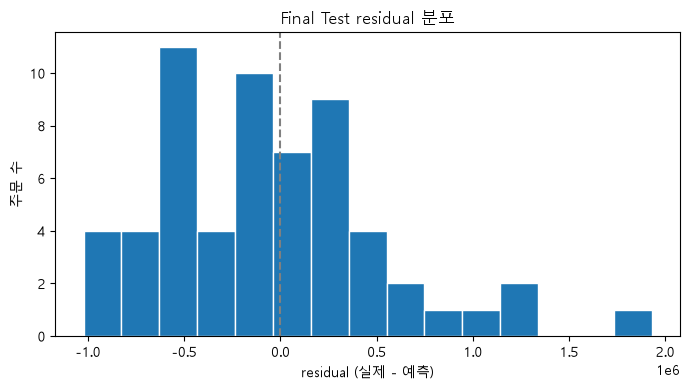

💾 저장: reports/ch09_regression_predictions_internal.csv (Internal: order_id 포함)
💾 저장: reports/figures/ch09_actual_vs_predicted.png, ch09_residual_histogram.png (공개 가능)


In [10]:
import matplotlib.pyplot as plt

# 한글 폰트 (Windows: 맑은 고딕)
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# ===== STEP 11. Frozen Model의 Final Test 오차 진단 =====
diag = test_df[["order_id", "order_date"] + FEATURES].copy()
diag["actual_order_total"]    = y_test.values
diag["predicted_order_total"] = frozen_pipe.predict(X_test).round()
diag["residual"]  = diag["actual_order_total"] - diag["predicted_order_total"]   # >0: 과소예측, <0: 과대예측
diag["abs_error"] = diag["residual"].abs()
diag["방향"] = np.where(diag["residual"] > 0, "과소예측(실제보다 낮게)", "과대예측(실제보다 높게)")

# 예측값 범위: 모델이 얼마나 다양한 값을 내는지
print("■ 예측값 vs 실제값 분포")
display(pd.DataFrame({"실제": diag["actual_order_total"].describe(),
                      "예측": diag["predicted_order_total"].describe()}).T.round())

print("■ residual 방향 요약")
display(diag.groupby("방향")["abs_error"].agg(건수="count", 평균오차="mean").round())

# 대표 큰 오차 사례 Top 3
top = diag.nlargest(3, "abs_error")
print("■ 대표 큰 오차 사례 Top 3 (abs_error 기준)")
display(top.drop(columns=["order_id"]))   # 화면·캡처에는 식별자 제외

# ===== 그래프 2개 =====
fig_dir = ROOT / "reports" / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(diag["actual_order_total"], diag["predicted_order_total"], alpha=0.7)
lim = [0, max(diag["actual_order_total"].max(), diag["predicted_order_total"].max()) * 1.05]
ax.plot(lim, lim, "--", color="gray", label="완벽한 예측 (y = x)")
ax.axhline(y_train.mean(), color="orange", linestyle=":", label=f"Train 평균 {y_train.mean():,.0f}")
ax.set(xlim=lim, ylim=lim, xlabel="실제 order_total", ylabel="예측 order_total",
       title=f"Final Test: 실제 vs 예측 ({SELECTED_MODEL})")
ax.legend(); plt.tight_layout()
fig.savefig(fig_dir / "ch09_actual_vs_predicted.png", dpi=120); plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(diag["residual"], bins=15, edgecolor="white")
ax.axvline(0, color="gray", linestyle="--")
ax.set(xlabel="residual (실제 - 예측)", ylabel="주문 수", title="Final Test residual 분포")
plt.tight_layout(); fig.savefig(fig_dir / "ch09_residual_histogram.png", dpi=120); plt.show()

# ===== Evidence 저장 =====
diag.to_csv(ROOT / "reports" / "ch09_regression_predictions_internal.csv", index=False, encoding="utf-8-sig")
print("💾 저장: reports/ch09_regression_predictions_internal.csv (Internal: order_id 포함)")
print("💾 저장: reports/figures/ch09_actual_vs_predicted.png, ch09_residual_histogram.png (공개 가능)")

## 대표 오차 사례

### 사례 1
- 실제값: 2,821,000 / 예측값: 891,352
- residual: +1,929,648 / absolute error: 1,929,648
- 관찰: Test 기간에서 가장 큰 주문(2026-05-31, 수원, kakao_pay)을 평균 근처로 예측했다.
- 가능한 이유 후보: 고객 특성과 날짜만으로는 고액 주문인지 구분할 신호가 부족할 수 있다. (가설)
- 추가 확인 사항: 이 고객의 과거 주문 이력이 고액 주문과 관련이 있는지

### 사례 2
- 실제값: 2,118,000 / 예측값: 908,778
- residual: +1,209,222 / absolute error: 1,209,222
- 관찰: 토요일 부산 주문(naver_pay)으로, 역시 고액 주문을 크게 과소예측했다.

### 사례 3
- 실제값: 2,053,000 / 예측값: 854,965
- residual: +1,198,035 / absolute error: 1,198,035
- 관찰: 토요일 부산 주문(bank_transfer, 19세)으로, 과소예측 패턴이 같다.

### 공통 패턴
- 관찰: 큰 오차 Top 3가 모두 200만 원 이상 주문의 과소예측이다. 예측값은 약 71만~114만 원 범위에만 분포한다.
- 가설: 현재 feature로는 고액 주문의 특성을 설명하지 못해, 모델이 평균 근처 값으로 수렴한 것일 수 있다.

### STEP 12~13. Validation Evidence와 공개 범위

In [11]:
# ===== STEP 12. 자동 Validation Evidence =====
audit = pd.read_csv(ROOT / "reports" / "ch09_regression_feature_audit.csv", encoding="utf-8-sig")
forbidden = set(audit.loc[audit["최종 사용"] == "제외", "feature"])
overlap = sorted(set(FEATURES) & forbidden)

validation = pd.DataFrame([
    ("forbidden_feature_overlap", len(overlap),
     len(overlap) == 0),
    ("strict_train_before_test", f"{train_df['order_date'].max().date()} < {test_df['order_date'].min().date()}",
     train_df["order_date"].max() < test_df["order_date"].min()),
    ("selected_model_exists_in_train_cv", SELECTED_MODEL,
     SELECTED_MODEL in cv_summary.loc[cv_summary["role"] == "candidate", "model"].values),
    ("final_test_contains_baseline", "Baseline Mean" in comparison["model"].values,
     (comparison["selection_role"] == "baseline").any()),
    ("final_test_contains_frozen_selected_model", f"Frozen {SELECTED_MODEL}",
     (comparison["selection_role"] == "selected_by_train_cv").any()),
    ("test_rows_for_r2", len(y_test),
     len(y_test) >= 30),
], columns=["check", "value", "passed"])
validation["status"] = np.where(validation["passed"], "PASS", "FAIL")
validation = validation.drop(columns="passed")

print("■ STEP 12. Validation Evidence")
display(validation)
if (validation["status"] == "PASS").all():
    print("✅ 모든 status == PASS → Chapter09 모델링 완료 조건 충족")
else:
    print("❌ FAIL 존재 → 모델링 완료로 처리하지 않음:", validation.loc[validation["status"] == "FAIL", "check"].tolist())

validation.to_csv(ROOT / "reports" / "ch09_regression_validation.csv", index=False, encoding="utf-8-sig")

# ===== STEP 13. Evidence와 공개 범위 구분 =====
# 공개용 보고서 생성 (식별자 없이 요약만)
report = f"""# Chapter09 회귀 분석 보고서 (Public)

- Target: order_total (주문 1건의 금액)
- Features: {', '.join(FEATURES)}
- Train: {train_df['order_date'].min().date()} ~ {train_df['order_date'].max().date()} ({len(train_df)}행)
- Final Test: {test_df['order_date'].min().date()} ~ {test_df['order_date'].max().date()} ({len(test_df)}행)
- Selected Model (Train CV로 선택): {SELECTED_MODEL}

## Final Test 결과
{comparison[['model', 'test_MAE', 'test_RMSE', 'test_R2', 'MAE_improvement_vs_baseline_pct']].to_markdown(index=False)}

## Validation
{validation.to_markdown(index=False)}

![actual vs predicted](figures/ch09_actual_vs_predicted.png)
![residual histogram](figures/ch09_residual_histogram.png)
"""
(ROOT / "reports" / "ch09_regression_report.md").write_text(report, encoding="utf-8")

ID_COLS = {"order_id", "customer_id", "product_id", "order_item_id", "name"}
def id_cols_in(path):
    if path.suffix != ".csv":
        return "-"
    cols = set(pd.read_csv(path, nrows=0, encoding="utf-8-sig").columns)
    found = sorted(cols & ID_COLS)
    return ", ".join(found) if found else "없음"

R = ROOT / "reports"
scope = [
    ("검증 Evidence", R / "ch09_regression_split_summary.csv"),
    ("검증 Evidence", R / "ch09_regression_feature_audit.csv"),
    ("검증 Evidence", R / "ch09_regression_cv_summary.csv"),
    ("검증 Evidence", R / "ch09_regression_model_comparison.csv"),
    ("검증 Evidence", R / "ch09_regression_validation.csv"),
    ("검증 Evidence", R / "ch09_regression_target_check.csv"),
    ("Internal",      ROOT / "data" / "processed" / "ch09_model_data.csv"),
    ("Internal",      R / "ch09_regression_predictions_internal.csv"),
    ("공개 보고서",   R / "ch09_regression_report.md"),
    ("공개 그래프",   R / "figures" / "ch09_actual_vs_predicted.png"),
    ("공개 그래프",   R / "figures" / "ch09_residual_histogram.png"),
]
scope_df = pd.DataFrame([{"구분": g, "파일": str(p.relative_to(ROOT)).replace("\\", "/"),
                          "존재": "O" if p.exists() else "X",
                          "식별자 컬럼": id_cols_in(p) if p.exists() else "-"} for g, p in scope])
print("\n■ STEP 13. Evidence와 공개 범위")
display(scope_df)

leak = scope_df[(scope_df["구분"] != "Internal") & ~scope_df["식별자 컬럼"].isin(["없음", "-"])]
print("✅ 공개 대상 파일에 식별자 없음" if leak.empty else f"⚠️ 공개 대상에 식별자 포함: {leak['파일'].tolist()}")
print("🔒 Internal 파일(order_id 포함)은 GitHub에 올리지 않도록 .gitignore에 추가 권장")

■ STEP 12. Validation Evidence


,check,value,status
0,forbidden_feature_overlap,0,PASS
1,strict_train_before_test,2026-05-24 < 2026-05-25,PASS
2,selected_model_exists_in_train_cv,Random Forest,PASS
3,final_test_contains_baseline,True,PASS
4,final_test_contains_frozen_selected_model,Frozen Random Forest,PASS
5,test_rows_for_r2,60,PASS


✅ 모든 status == PASS → Chapter09 모델링 완료 조건 충족

■ STEP 13. Evidence와 공개 범위


,구분,파일,존재,식별자 컬럼
0,검증 Evidence,reports/ch09_regression_split_summary.csv,O,없음
1,검증 Evidence,reports/ch09_regression_feature_audit.csv,O,없음
2,검증 Evidence,reports/ch09_regression_cv_summary.csv,O,없음
3,검증 Evidence,reports/ch09_regression_model_comparison.csv,O,없음
4,검증 Evidence,reports/ch09_regression_validation.csv,O,없음
5,검증 Evidence,reports/ch09_regression_target_check.csv,O,없음
6,Internal,data/processed/ch09_model_data.csv,O,order_id
7,Internal,reports/ch09_regression_predictions_internal.csv,O,order_id
8,공개 보고서,reports/ch09_regression_report.md,O,-
9,공개 그래프,reports/figures/ch09_actual_vs_predicted.png,O,-


✅ 공개 대상 파일에 식별자 없음
🔒 Internal 파일(order_id 포함)은 GitHub에 올리지 않도록 .gitignore에 추가 권장


## Validation Evidence
| check | value | status |
|---|---|---|
| forbidden_feature_overlap | 0 | PASS |
| strict_train_before_test | 2026-05-24 < 2026-05-25 | PASS |
| selected_model_exists_in_train_cv | Random Forest | PASS |
| final_test_contains_baseline | True | PASS |
| final_test_contains_frozen_selected_model | Frozen Random Forest | PASS |
| test_rows_for_r2 | 60 | PASS |

## Evidence와 공개 범위
- 공개 가능한 Evidence: split_summary, feature_audit, cv_summary, model_comparison, validation, target_check CSV, report.md, figures 그래프 2장
- Internal로만 유지할 파일: data/processed/ch09_model_data.csv, reports/ch09_regression_predictions_internal.csv
- Internal로 구분한 이유: order_id 식별자가 들어 있어 개별 주문을 추적할 수 있다. 분석 결론을 전달하는 데는 식별자가 필요 없다.

### STEP 14. 전체 재실행 확인

In [12]:
import subprocess, sys, json, os

# ===== STEP 14. 전체 파이프라인을 처음부터 다시 실행 =====
# Notebook 메모리 상태와 무관하게, 새 프로세스에서 data/raw부터 다시 실행
nb_result = {
    "selected_model": SELECTED_MODEL,
    "test_MAE": int(comparison.iloc[1]["test_MAE"]),
    "test_RMSE": int(comparison.iloc[1]["test_RMSE"]),
    "test_R2": float(comparison.iloc[1]["test_R2"]),
}

proc = subprocess.run([sys.executable, "scripts/run_ch09_regression.py", "--quiet"],
                      cwd=ROOT, capture_output=True, text=True, encoding="utf-8",
                      env={**os.environ, "PYTHONIOENCODING": "utf-8"})   # Windows 한글·이모지 출력 깨짐 방지
print("■ 스크립트 실행 로그 (마지막 부분)")
print("\n".join(proc.stdout.strip().splitlines()[-4:]))
if proc.returncode != 0:
    print(proc.stderr[-2000:])
assert proc.returncode == 0, "❌ 전체 재실행 실패"

rerun = json.loads((ROOT / "reports" / "ch09_regression_rerun_summary.json").read_text(encoding="utf-8"))

rerun_check = pd.DataFrame([
    ("입력 준비 + 회귀 스크립트 실행", "returncode 0", "성공", "PASS"),
    ("Selected Model", nb_result["selected_model"], rerun["selected_model"],
     "PASS" if nb_result["selected_model"] == rerun["selected_model"] else "FAIL"),
    ("Final Test MAE",  nb_result["test_MAE"],  rerun["test_MAE"],
     "PASS" if abs(nb_result["test_MAE"] - rerun["test_MAE"]) <= 1 else "FAIL"),
    ("Final Test RMSE", nb_result["test_RMSE"], rerun["test_RMSE"],
     "PASS" if abs(nb_result["test_RMSE"] - rerun["test_RMSE"]) <= 1 else "FAIL"),
    ("Final Test R²",   nb_result["test_R2"],   rerun["test_R2"],
     "PASS" if abs(nb_result["test_R2"] - rerun["test_R2"]) < 1e-3 else "FAIL"),
    ("Final Validation 전체 PASS", "-", rerun["validation_all_pass"],
     "PASS" if rerun["validation_all_pass"] else "FAIL"),
], columns=["항목", "Notebook", "스크립트 재실행", "status"])
print("\n■ Notebook vs 전체 재실행 비교")
display(rerun_check)
print("✅ Notebook과 스크립트 결과 일치" if (rerun_check["status"] == "PASS").all() else "❌ 불일치 항목 확인 필요")

■ 스크립트 실행 로그 (마지막 부분)

전체 재실행 완료: {"selected_model": "Random Forest", "train_rows": 240, "test_rows": 60, "test_MAE": 451811, "test_RMSE": 578482, "test_R2": -0.0253, "baseline_test_MAE": 455562, "validation_all_pass": true}

■ Notebook vs 전체 재실행 비교


,항목,Notebook,스크립트 재실행,status
0,입력 준비 + 회귀 스크립트 실행,returncode 0,성공,PASS
1,Selected Model,Random Forest,Random Forest,PASS
2,Final Test MAE,451811,451811,PASS
3,Final Test RMSE,578482,578482,PASS
4,Final Test R²,-0.0253,-0.0253,PASS
5,Final Validation 전체 PASS,-,True,PASS


✅ Notebook과 스크립트 결과 일치


## 전체 재실행 확인
- 입력 준비 성공 여부: 성공 (data/raw → FK 검증 PASS → data/processed 저장)
- 회귀 스크립트 실행 성공 여부: 성공 (scripts/run_ch09_regression.py)
- Train CV Selected Model: Random Forest (Notebook과 동일)
- Final Validation 전체 PASS 여부: PASS (6/6)
- Notebook과 스크립트 결과의 일관성: Test MAE 451,811 / RMSE 578,482 / R² -0.0253로 동일

### STEP 15. 최종 사용 판단 (답안 Markdown)

## 최종 사용 판단
- **현재 데이터로는 사용 보류**

### 판단 근거
1. Baseline 대비 성능 차이가 거의 없다. Final Test MAE는 0.82%만 개선됐고, RMSE(578,482 vs 572,033)와 R²(-0.025 vs -0.003)는 오히려 Baseline보다 나쁘다.
2. Train CV에서도 두 후보 모두 Baseline보다 MAE가 컸다. Random Forest는 비베이스라인 후보 중 MAE가 가장 낮아서 규칙에 따라 선택됐을 뿐, 평균 예측보다 나은 모델은 아니었다.
3. 예측값이 약 71만~114만 원 범위에 몰려 있다. 200만 원 이상 고액 주문을 크게 과소예측해서, 오차 Top 3가 모두 고액 주문이었다.

※ 누수 검증(forbidden_feature_overlap 0), 시간 분할 검증, Validation 6개 항목은 모두 PASS다. 평가 절차는 올바르며, 낮은 성능은 절차 문제가 아니라 현재 입력 정보의 한계로 본다.

### 업무적 위험
- 평균 주문 금액(약 83만 원) 대비 평균 오차가 약 45만 원이다. 이 예측으로 재고나 매출 계획을 세우면 오판할 위험이 크다.
- 특히 고액 주문을 과소예측하는 경향이 있어, 매출을 낮게 잡는 쪽으로 치우칠 수 있다.

### 현재 데이터의 한계
- 사용 가능한 feature가 고객 특성 3개(gender, age, city)와 주문 메타데이터 3개뿐이다.
- 데이터가 300건(Final Test 60건)이라 지표가 쉽게 흔들린다.
- 누수 방지를 위해 주문 상세(상품, 수량)를 제외했기 때문에, 금액을 설명할 핵심 정보가 입력에 없다.

### 다음 개선 우선순위
1. 예측 시점에 알 수 있는 고객 이력 feature 추가: 해당 주문 이전의 과거 평균 주문 금액, 주문 횟수, 가입 기간(signup_date 활용). 단, 해당 주문 이후 정보가 섞이지 않게 만든다.
2. 데이터 기간과 건수를 늘려 다시 검증하고, 새로운 미래 구간을 Final Test로 사용
3. 고액 주문 여부를 먼저 분류하는 등 문제 정의 자체를 다시 검토

## LLM 활용 기록
### 사용 목적
Feature Leakage 검토, 단계별 코드 초안 작성, 지표 해석 검토

### 사용한 프롬프트 요약
- Target은 order_total, Target 계산 재료·ID·사후 정보 제외
- 실제 data/raw 컬럼 기준으로 Audit 표 작성
- 시간 순서 분할, Train TimeSeriesSplit, Final Test 전 모델 고정, Baseline 비교

### LLM 제안 중 수정한 내용
- STEP 9 실행 시 SELECTED_MODEL 미정의 오류 → STEP 7~8을 먼저 실행하도록 순서 수정 (값을 직접 적어 넣지 않음)
- products의 price·category는 가이드 금지 목록에 없었지만, 주문 상세를 통해서만 연결되는 정보로 판단해 제외

### 최종 판단은 누가 했는가
분석자인 내가 Evidence를 확인한 뒤 결정함

In [13]:
new_orders = pd.DataFrame([
    {"gender": "F", "age": 25, "city": "서울", "payment_method": "card",          "order_month": 10, "order_dayofweek": 5},
    {"gender": "M", "age": 55, "city": "부산", "payment_method": "bank_transfer", "order_month": 10, "order_dayofweek": 1},
    {"gender": "F", "age": 40, "city": "제주", "payment_method": "kakao_pay",     "order_month": 12, "order_dayofweek": 6},
])
new_orders["예측 주문 금액"] = frozen_pipe.predict(new_orders).round(-3)
new_orders

,gender,age,city,payment_method,order_month,order_dayofweek,예측 주문 금액
0,F,25,서울,card,10,5,759000.0
1,M,55,부산,bank_transfer,10,1,874000.0
2,F,40,제주,kakao_pay,12,6,1009000.0
